<a href="https://www.kaggle.com/code/maazali04/house-prices-prediction?scriptVersionId=334967506" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
data["Alley"].unique()

array([nan, 'Grvl', 'Pave'], dtype=object)

In [6]:
data.shape

(1460, 81)

In [7]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
pd.set_option('display.max_rows', None)
data.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [10]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Handling missing values ....

In [11]:
data["HasAlley"] = data["Alley"].notnull().astype(int)
data.drop("Alley", axis=1, inplace=True)

In [12]:
data["HasFireplaceQu"] = data["FireplaceQu"].notnull().astype(int)
data.drop("FireplaceQu", axis=1, inplace=True)

In [13]:
data["HasPoolQC"] = data["PoolQC"].notnull().astype(int)
data.drop("PoolQC", axis=1, inplace=True)

In [14]:
data["HasFence"] = data["Fence"].notnull().astype(int)
data.drop("Fence", axis=1, inplace=True)

In [15]:
data["HasMiscFeature"] = data["MiscFeature"].notnull().astype(int)
data.drop("MiscFeature", axis=1, inplace=True)

In [16]:
data["HasMasVnrType"] = data["MasVnrType"].notnull().astype(int)
data.drop("MasVnrType", axis=1, inplace=True)

In [17]:
data["LotFrontage"].fillna(data["LotFrontage"].median(), inplace=True)

/tmp/ipykernel_16/2279437000.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["LotFrontage"].fillna(data["LotFrontage"].median(), inplace=True)


In [18]:
data.fillna({"MasVnrArea":0},inplace=True)
data.fillna({"GarageYrBlt":0},inplace=True)

In [19]:
none_cols = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]
data[none_cols] = data[none_cols].fillna('None')

In [20]:
data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

In [21]:
data['HouseAgeAtSale'] = data['YrSold'] - data['YearBuilt']

In [22]:
data['YearsSinceRemodelAtSale'] = data['YrSold'] - data['YearRemodAdd']

In [23]:
data['GarageAgeAtSale'] = np.where(
    data['GarageYrBlt'] > 0, 
    data['YrSold'] - data['GarageYrBlt'], 
    -1 # Using -1 as a flag to indicate "No Garage" to the linear model
)

data = data.drop(columns=['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold'])

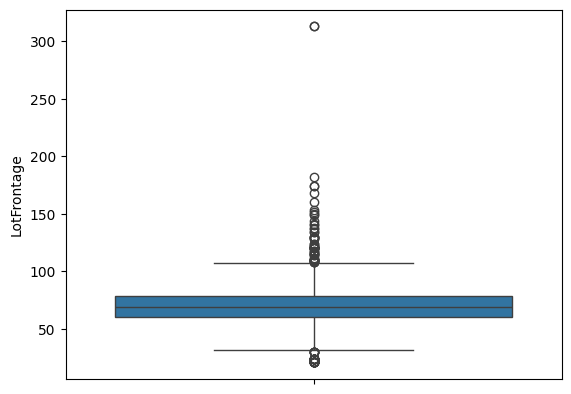

In [24]:
sns.boxplot(data["LotFrontage"]);

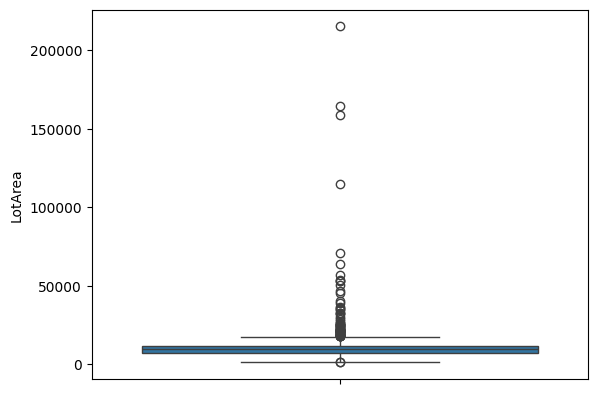

In [25]:
sns.boxplot(data["LotArea"]);

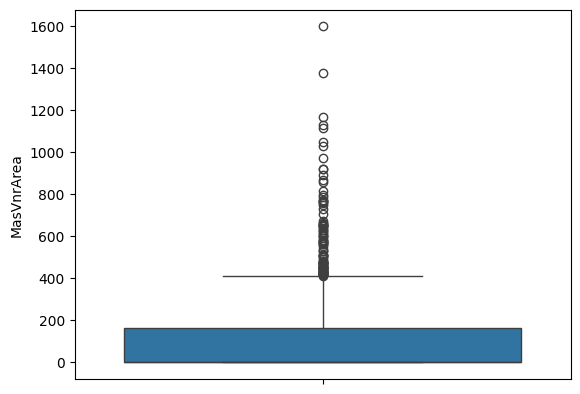

In [26]:
sns.boxplot(data["MasVnrArea"]);

In [27]:
outlier_cols = ['LotFrontage', 'LotArea', 'MasVnrArea']

for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    data = data[
        (data[col] >= lower_bound) & (data[col] <= upper_bound)
    ]

In [28]:
data.columns [data.dtypes == "int"]

Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'SalePrice', 'HasAlley', 'HasFireplaceQu', 'HasPoolQC',
       'HasFence', 'HasMiscFeature', 'HasMasVnrType', 'HouseAgeAtSale',
       'YearsSinceRemodelAtSale'],
      dtype='object')

In [29]:
y = data["SalePrice"]
x = data.drop(["Id","SalePrice"], axis=1)
x['MSSubClass'] = x['MSSubClass'].astype(str)


cols_to_encode = x.select_dtypes(include=['object']).columns.tolist()

exclude_cols = [
    'Id', 'MSSubClass', 'SalePrice',
    'HasAlley', 'HasFireplaceQu', 'HasPoolQC', 
    'HasFence', 'HasMiscFeature', 'HasMasVnrType'
]

all_numeric = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_to_scale = [col for col in all_numeric if col not in exclude_cols]


scaler = StandardScaler()
x[cols_to_scale] = scaler.fit_transform(x[cols_to_scale])

x = pd.get_dummies(x, columns=cols_to_encode, drop_first=True, dtype=int)

print(x.shape)

(1209, 245)


Model Training ...

In [30]:
from sklearn.linear_model import SGDRegressor, Lasso, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import cross_val_score
import numpy as np

y_log = np.log1p(data['SalePrice'])

models = {
    "SGDRegressor": SGDRegressor(alpha=0.0005),
    "ElasticNet":ElasticNet(alpha=0.0005),
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=10000),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

print("--- MODEL ACCURACY (R2 SCORE) ---")


for name, model in models.items():
    r2_scores = cross_val_score(model, x, y_log, cv=5, scoring='r2')
    
    rmse_scores = np.sqrt(-cross_val_score(model, x, y_log, cv=5, scoring='neg_mean_squared_error'))
    
    print(f"{name.ljust(18)} -> R2 Accuracy: {r2_scores.mean() * 100:.2f}% | Log-RMSE: {rmse_scores.mean():.4f}")

--- MODEL ACCURACY (R2 SCORE) ---
SGDRegressor       -> R2 Accuracy: -2.90% | Log-RMSE: 0.3762
ElasticNet         -> R2 Accuracy: 90.95% | Log-RMSE: 0.1098
Ridge              -> R2 Accuracy: 90.75% | Log-RMSE: 0.1110
Lasso              -> R2 Accuracy: 90.73% | Log-RMSE: 0.1111
SVR                -> R2 Accuracy: 86.53% | Log-RMSE: 0.1343
RandomForest       -> R2 Accuracy: 85.87% | Log-RMSE: 0.1372
GradientBoosting   -> R2 Accuracy: 88.05% | Log-RMSE: 0.1263
KNN                -> R2 Accuracy: 80.96% | Log-RMSE: 0.1596


Hyper-Tuning and checkign for overfitting ....

In [31]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'alpha': [0.0001, 0.0003, 0.0005, 0.001, 0.005, 0.01],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
}

elastic_net_base = ElasticNet(max_iter=20000, random_state=42)
grid_search = GridSearchCV(
    estimator=elastic_net_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',
    return_train_score=True # Crucial for checking overfitting!
)

grid_search.fit(x, y_log)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_


best_index = grid_search.best_index_
mean_train_r2 = grid_search.cv_results_['mean_train_score'][best_index] * 100
mean_val_r2 = grid_search.best_score_ * 100
overfitting_gap = mean_train_r2 - mean_val_r2

print("=== HYPERPARAMETER TUNING RESULTS ===")
print(f"Optimal Alpha: {best_params['alpha']}")
print(f"Optimal L1 Ratio: {best_params['l1_ratio']}\n")

print("=== OVERFITTING VERIFICATION ===")
print(f"Mean Training R2 Score:   {mean_train_r2:.2f}%")
print(f"Mean Validation R2 Score: {mean_val_r2:.2f}%")
print(f"Generalization Gap:       {overfitting_gap:.2f}%")

if overfitting_gap > 5.0:
    print("\n[WARNING]: The gap is wider than 5%. The model might be memorizing training variance.")
else:
    print("\n[VERDICT]: The model is highly robust! The low gap confirms no significant overfitting.")

=== HYPERPARAMETER TUNING RESULTS ===
Optimal Alpha: 0.0003
Optimal L1 Ratio: 0.9

=== OVERFITTING VERIFICATION ===
Mean Training R2 Score:   93.86%
Mean Validation R2 Score: 90.98%
Generalization Gap:       2.88%

[VERDICT]: The model is highly robust! The low gap confirms no significant overfitting.


Making prediction on test data ....

In [32]:
test_data = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [33]:
test_data.isnull().sum()

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       227
LotArea             0
Street              0
Alley            1352
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType        894
MasVnrArea         15
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           44
BsmtCond           45
BsmtExposure       44
BsmtFinType1       42
BsmtFinSF1          1
BsmtFinType2       42
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [34]:
test_data["HasAlley"]       = test_data["Alley"].notnull().astype(int)
test_data["HasFireplaceQu"] = test_data["FireplaceQu"].notnull().astype(int)
test_data["HasPoolQC"]      = test_data["PoolQC"].notnull().astype(int)
test_data["HasFence"]       = test_data["Fence"].notnull().astype(int)
test_data["HasMiscFeature"]  = test_data["MiscFeature"].notnull().astype(int)
test_data["HasMasVnrType"]   = test_data["MasVnrType"].notnull().astype(int)

test_data.drop(columns=["Alley", "FireplaceQu", "PoolQC", "Fence", "MiscFeature", "MasVnrType"], inplace=True)

test_data["LotFrontage"] = test_data["LotFrontage"].fillna(data["LotFrontage"].median())
test_data = test_data.fillna({"MasVnrArea": 0, "GarageYrBlt": 0})

none_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
test_data[none_cols] = test_data[none_cols].fillna('None')
test_data["Electrical"] = test_data["Electrical"].fillna(data["Electrical"].mode()[0])

test_data['HouseAgeAtSale'] = test_data['YrSold'] - test_data['YearBuilt']
test_data['YearsSinceRemodelAtSale'] = test_data['YrSold'] - test_data['YearRemodAdd']
test_data['GarageAgeAtSale'] = np.where(
    test_data['GarageYrBlt'] > 0, 
    test_data['YrSold'] - test_data['GarageYrBlt'], 
    -1 
)

test_data = test_data.drop(columns=['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold'])

In [35]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,SaleCondition,HasAlley,HasFireplaceQu,HasPoolQC,HasFence,HasMiscFeature,HasMasVnrType,HouseAgeAtSale,YearsSinceRemodelAtSale,GarageAgeAtSale
0,1461,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,...,Normal,0,0,0,1,0,0,49,49,49.0
1,1462,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,...,Normal,0,0,0,0,1,1,52,52,52.0
2,1463,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,...,Normal,0,1,0,1,0,0,13,12,13.0
3,1464,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,...,Normal,0,1,0,0,0,1,12,12,12.0
4,1465,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,...,Normal,0,0,0,0,0,0,18,18,18.0


In [36]:
test_data.columns[test_data.isnull().sum()>0]

Index(['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea',
       'SaleType'],
      dtype='object')

In [37]:
test_exclusive_cat_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
for col in test_exclusive_cat_cols:
    test_data[col] = test_data[col].fillna(data[col].mode()[0])

test_exclusive_num_cols = [
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]
for col in test_exclusive_num_cols:
    test_data[col] = test_data[col].fillna(0)

In [38]:
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    test_data[col] = test_data[col].clip(lower=lower_bound, upper=upper_bound)

test_x = test_data.drop(["Id"], axis=1)
test_x['MSSubClass'] = test_x['MSSubClass'].astype(str)

test_x[cols_to_scale] = scaler.transform(test_x[cols_to_scale])

test_x = pd.get_dummies(test_x, columns=cols_to_encode, drop_first=True, dtype=int)

test_x = test_x.reindex(columns=x.columns, fill_value=0)

print(f"Final training matrix shape: {x.shape}")
print(f"Final test matrix shape:     {test_x.shape}")

Final training matrix shape: (1209, 245)
Final test matrix shape:     (1459, 245)


In [39]:
pred_x = best_model.predict(test_x)
final_predictions = np.expm1(pred_x)


submission = pd.DataFrame({
    "Id": test_data["Id"],
    "SalePrice": final_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission file successfully created!")

Submission file successfully created!
